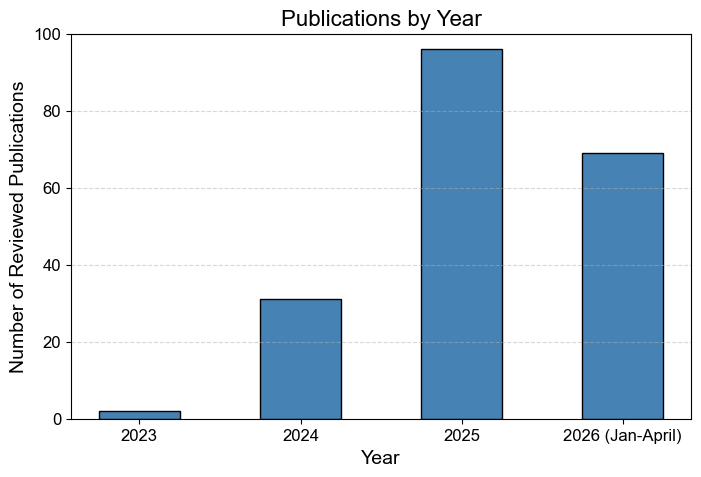

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
file_path = "Dataset.xlsx"  # Ensure the file is in the correct path
df = pd.read_excel(file_path)

# Count the number of publications per year
year_counts = df["Year"].value_counts().sort_index()

# Filter to only include 2022, 2023, 2024, and 2025
valid_years = [2023, 2024, 2025,2026]
year_counts = year_counts[year_counts.index.isin(valid_years)]

# Set font style to Times
plt.rcParams["font.family"] = "Arial"

# Custom labels for X-axis
custom_labels = ["2023", "2024", "2025", "2026 (Jan-April)"]

# Plot the bar chart with adjusted width
plt.figure(figsize=(8, 5))
plt.bar(year_counts.index, year_counts.values, color='steelblue', edgecolor='black', width=0.5)

# Formatting the plot
plt.xlabel("Year", fontsize=14)
plt.ylabel("Number of Reviewed Publications", fontsize=14)
plt.title("Publications by Year", fontsize=16)
plt.xticks(valid_years, labels=custom_labels, fontsize=12)  # Custom labels for x-axis
plt.yticks(fontsize=12)
plt.ylim(0, 100)  # Set Y-axis range from 0 to 50
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Show the plot
plt.show()


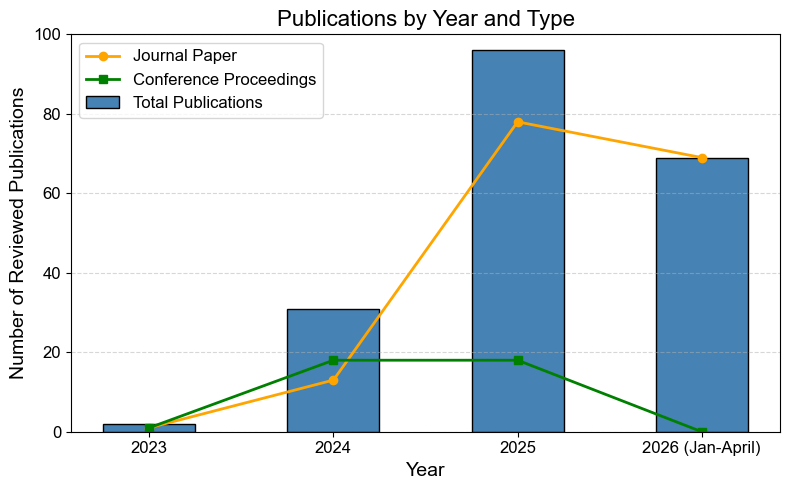

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
file_path = "Dataset.xlsx"  # Ensure the file is in the correct path
df = pd.read_excel(file_path)

# Define valid years and type mappings
valid_years = [2023, 2024, 2025, 2026]
type_mapping = {"J": "Journal", "C": "Conference Proceedings"}

# Count total publications per year
year_counts = df["Year"].value_counts().sort_index()
year_counts = year_counts[year_counts.index.isin(valid_years)]

# Count publications per year for each type
llm_counts = df[df["TYPE"] == "J"]["Year"].value_counts().sort_index()
mlm_counts = df[df["TYPE"] == "C"]["Year"].value_counts().sort_index()

# Ensure all years are present in the index (fill missing years with 0)
llm_counts = llm_counts.reindex(valid_years, fill_value=0)
mlm_counts = mlm_counts.reindex(valid_years, fill_value=0)

# Set font style to Arial
plt.rcParams["font.family"] = "Arial"

# Custom labels for X-axis
custom_labels = ["2023", "2024", "2025", "2026 (Jan-April)"]

# Plot the bar chart
plt.figure(figsize=(8, 5))
plt.bar(year_counts.index, year_counts.values, color='steelblue', edgecolor='black', width=0.5, label="Total Publications")

# Plot LLM and MLM counts as lines
plt.plot(valid_years, llm_counts.values, color='orange', marker='o', linewidth=2, label="Journal Paper")
plt.plot(valid_years, mlm_counts.values, color='green', marker='s', linewidth=2, label="Conference Proceedings")

# Formatting the plot
plt.xlabel("Year", fontsize=14)
plt.ylabel("Number of Reviewed Publications", fontsize=14)
plt.title("Publications by Year and Type", fontsize=16)
plt.xticks(valid_years, labels=custom_labels, fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(fontsize=12)

# Show the plot
plt.tight_layout()
plt.savefig('Count.png', dpi=1000)
plt.show()


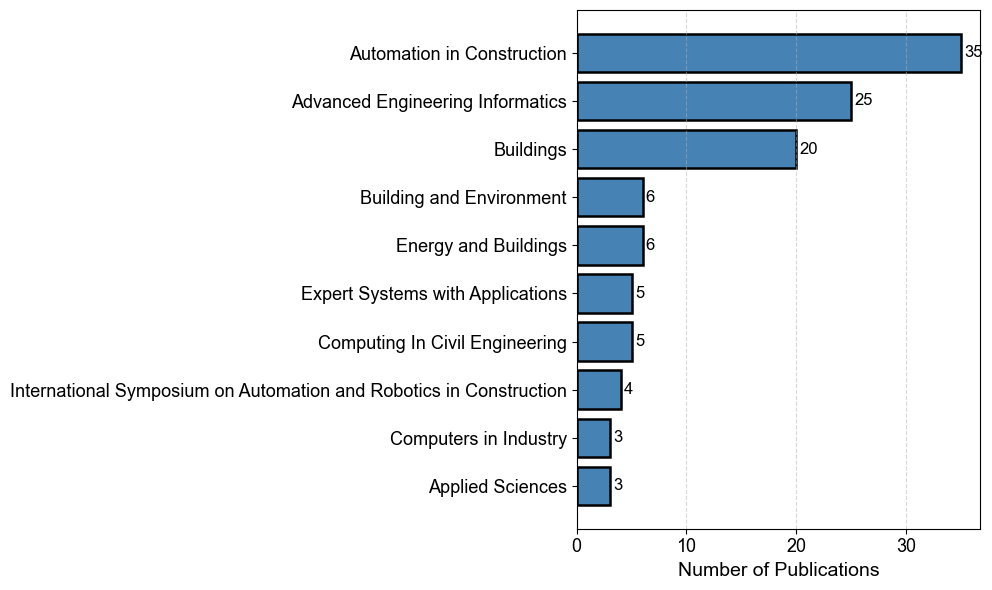

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# Standardize / shorten venue names
# --------------------------------------------------
venue_short = {

    "Proceedings of the International Symposium on Automation and Robotics in Construction": "International Symposium on Automation and Robotics in Construction",

}

df_plot = df.copy()
df_plot["Journal"] = df_plot["Journal"].replace(venue_short)

# --------------------------------------------------
# Top 10 venues
# --------------------------------------------------
venue_counts = (
    df_plot.groupby("Journal")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
ax.set_facecolor("white")

bars = ax.barh(
    venue_counts.index[::-1],      # highest at top
    venue_counts.values[::-1],
    color="steelblue",
    edgecolor="black",
    linewidth=1.8
)

# --------------------------------------------------
# Labels and title
# --------------------------------------------------


ax.set_xlabel(
    "Number of Publications",
    fontsize=14
)

ax.set_ylabel("")

ax.tick_params(axis='x', labelsize=13)
ax.tick_params(axis='y', labelsize=13)

# --------------------------------------------------
# Grid
# --------------------------------------------------
ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.5
)

# --------------------------------------------------
# Count labels
# --------------------------------------------------
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.3,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va='center',
        fontsize=12
    )

# --------------------------------------------------
# Layout
# --------------------------------------------------
plt.tight_layout()

# Optional: save figure
plt.savefig("Top_Publication_Venues.png", dpi=600, bbox_inches="tight")

plt.show()

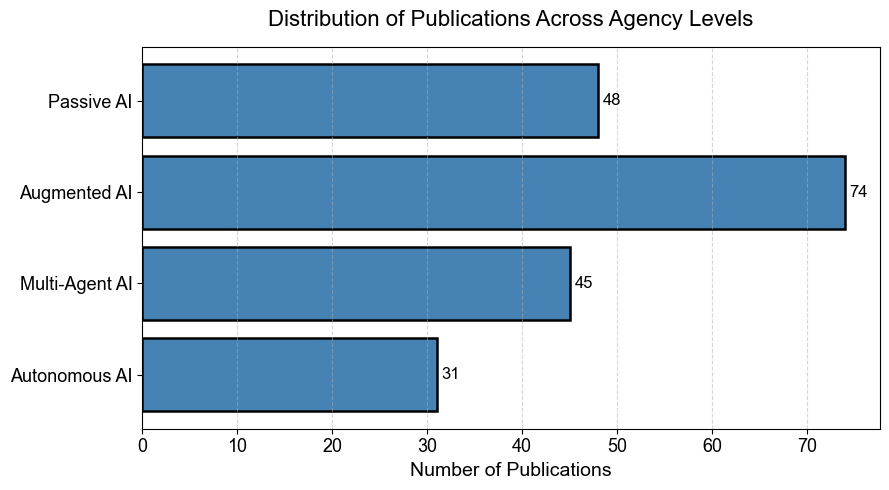

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# Agency level mapping
# --------------------------------------------------
agency_map = {
    1: "Passive AI",
    2: "Augmented AI",
    3: "Multi-Agent AI",
    4: "Autonomous AI"
}

agency_counts = (
    df["1. Level of agency"]
    .map(agency_map)
    .value_counts()
    .reindex([
        "Passive AI",
        "Augmented AI",
        "Multi-Agent AI",
        "Autonomous AI"
    ])
)

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5), facecolor="white")
ax.set_facecolor("white")

bars = ax.barh(
    agency_counts.index[::-1],      # highest level on top
    agency_counts.values[::-1],
    color="steelblue",
    edgecolor="black",
    linewidth=1.8
)

# --------------------------------------------------
# Labels
# --------------------------------------------------
ax.set_title(
    "Distribution of Publications Across Agency Levels",
    fontsize=16,
    pad=15
)

ax.set_xlabel(
    "Number of Publications",
    fontsize=14
)

ax.set_ylabel("")

ax.tick_params(axis='both', labelsize=13)

# Grid
ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.5
)

# Count labels
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va='center',
        fontsize=12
    )

plt.tight_layout()
plt.savefig("agency levels.png", dpi=800, bbox_inches="tight")

plt.show()

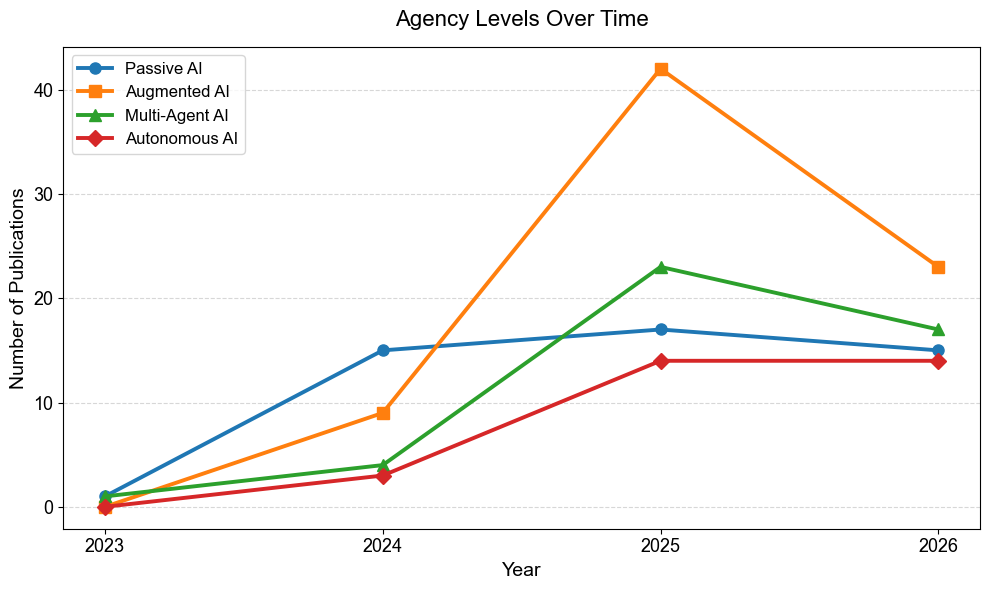

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# Agency level mapping
# --------------------------------------------------
agency_map = {
    1: "Passive AI",
    2: "Augmented AI",
    3: "Multi-Agent AI",
    4: "Autonomous AI"
}

df_plot = df.copy()

# Convert agency levels to labels
df_plot["Agency Level"] = df_plot["1. Level of agency"].map(agency_map)

# Ensure year is clean
df_plot["Year"] = df_plot["Year"].astype(str)

# --------------------------------------------------
# Count agency levels by year
# --------------------------------------------------
agency_by_year = (
    df_plot
    .groupby(["Year", "Agency Level"])
    .size()
    .unstack(fill_value=0)
)

# Ensure consistent agency-level order
agency_order = [
    "Passive AI",
    "Augmented AI",
    "Multi-Agent AI",
    "Autonomous AI"
]

agency_by_year = agency_by_year.reindex(columns=agency_order, fill_value=0)

# Ensure years are sorted correctly
agency_by_year = agency_by_year.sort_index()

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
ax.set_facecolor("white")

markers = {
    "Passive AI": "o",
    "Augmented AI": "s",
    "Multi-Agent AI": "^",
    "Autonomous AI": "D"
}

for level in agency_order:
    ax.plot(
        agency_by_year.index,
        agency_by_year[level],
        marker=markers[level],
        linewidth=2.8,
        markersize=8,
        label=level
    )

# --------------------------------------------------
# Labels and title
# --------------------------------------------------
ax.set_title(
    "Agency Levels Over Time",
    fontsize=16,
    pad=15
)

ax.set_xlabel(
    "Year",
    fontsize=14
)

ax.set_ylabel(
    "Number of Publications",
    fontsize=14
)

ax.tick_params(axis="both", labelsize=13)

# Grid
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

# Legend
ax.legend(
    fontsize=12,
    frameon=True,
    loc="upper left"
)

plt.tight_layout()

# Optional save
plt.savefig("Agency_Level_Trend.png", dpi=800, bbox_inches="tight")

plt.show()

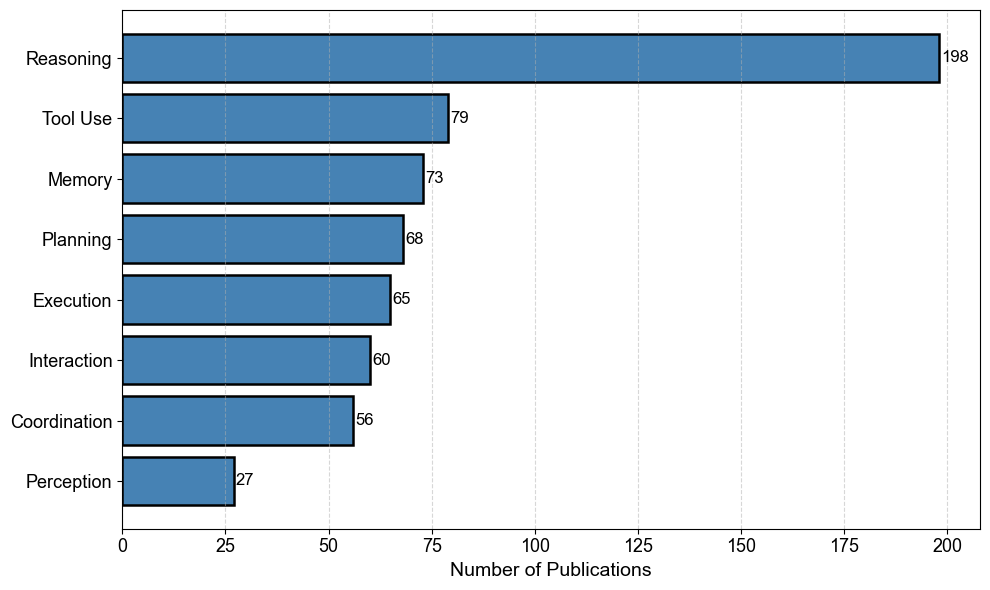

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# --------------------------------------------------
# Taxonomy-defined capability terms
# --------------------------------------------------
taxonomy_capabilities = [
    "Reasoning",
    "Planning",
    "Memory",
    "Tool Use",
    "Perception",
    "Interaction",
    "Coordination",
    "Execution"
]

# --------------------------------------------------
# Extract and count only taxonomy-defined capabilities
# --------------------------------------------------
capability_counter = Counter()

for item in df["2. Type of agentic capability"].dropna():
    capabilities = [c.strip() for c in str(item).split(",")]
    
    for capability in capabilities:
        if capability in taxonomy_capabilities:
            capability_counter[capability] += 1

# Keep taxonomy order, not random order
capability_counts = pd.DataFrame({
    "Capability": taxonomy_capabilities,
    "Count": [capability_counter.get(c, 0) for c in taxonomy_capabilities]
})

# Sort by count for plotting
capability_counts = capability_counts.sort_values("Count", ascending=False)

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
ax.set_facecolor("white")

bars = ax.barh(
    capability_counts["Capability"][::-1],
    capability_counts["Count"][::-1],
    color="steelblue",
    edgecolor="black",
    linewidth=1.8
)



ax.set_xlabel("Number of Publications", fontsize=14)
ax.set_ylabel("")

ax.tick_params(axis="x", labelsize=13)
ax.tick_params(axis="y", labelsize=13)

ax.grid(axis="x", linestyle="--", alpha=0.5)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va="center",
        fontsize=12
    )

plt.tight_layout()

# Optional save
plt.savefig("Agentic_Capabilities.png", dpi=800, bbox_inches="tight")

plt.show()

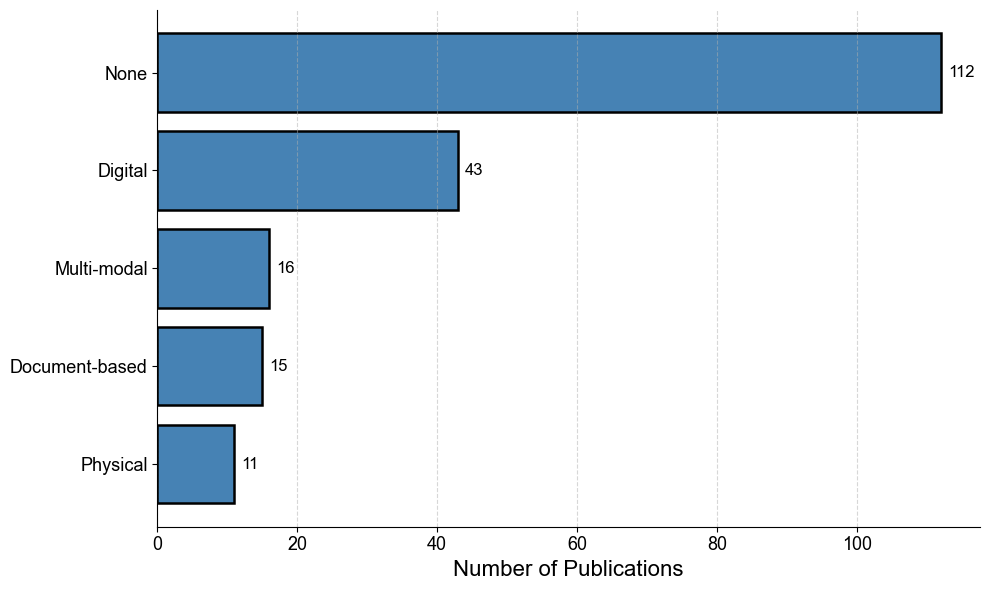

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# Environment interaction counts
# --------------------------------------------------
interaction_counts = pd.DataFrame({
    "Environment": [
        "None",
        "Digital",
        "Multi-modal",
        "Document-based",
        "Physical"
    ],
    "Count": [
        112,
        43,
        16,
        15,
        11
    ]
})

# Sort descending
interaction_counts = interaction_counts.sort_values(
    "Count",
    ascending=False
)

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
ax.set_facecolor("white")

bars = ax.barh(
    interaction_counts["Environment"][::-1],
    interaction_counts["Count"][::-1],
    color="steelblue",
    edgecolor="black",
    linewidth=1.8
)

# --------------------------------------------------
# Formatting
# --------------------------------------------------


ax.set_xlabel(
    "Number of Publications",
    fontsize=16
)

ax.set_ylabel("")

ax.tick_params(axis='x', labelsize=13)
ax.tick_params(axis='y', labelsize=13)

ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.5
)

# Add count labels
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 1,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va='center',
        fontsize=12
    )

# Clean look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# Optional save
plt.savefig("Figure12_EnvironmentInteraction.png", dpi=800, bbox_inches="tight")

plt.show()

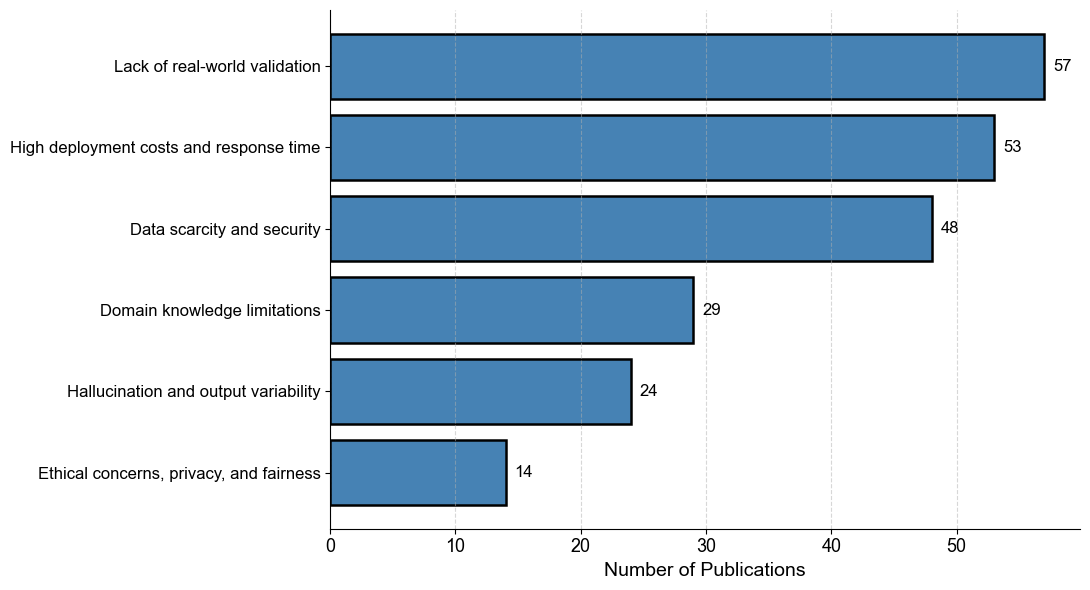

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# Limitation frequencies
# --------------------------------------------------
limitations = pd.DataFrame({
    "Limitation": [
        "Lack of real-world validation",
        "High deployment costs and response time",
        "Data scarcity and security",
        "Domain knowledge limitations",
        "Hallucination and output variability",
        "Ethical concerns, privacy, and fairness"
    ],
    "Count": [
        57,
        53,
        48,
        29,
        24,
        14
    ]
})

# Sort descending
limitations = limitations.sort_values(
    "Count",
    ascending=False
)

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 6), facecolor="white")
ax.set_facecolor("white")

bars = ax.barh(
    limitations["Limitation"][::-1],
    limitations["Count"][::-1],
    color="steelblue",
    edgecolor="black",
    linewidth=1.8
)

# --------------------------------------------------
# Formatting
# --------------------------------------------------


ax.set_xlabel(
    "Number of Publications",
    fontsize=14
)

ax.set_ylabel("")

ax.tick_params(axis='x', labelsize=13)
ax.tick_params(axis='y', labelsize=12)

ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.5
)

# Add labels
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.7,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va='center',
        fontsize=12
    )

# Clean look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# Optional save
plt.savefig("Figure13_ReportedLimitations.png", dpi=800, bbox_inches="tight")

plt.show()

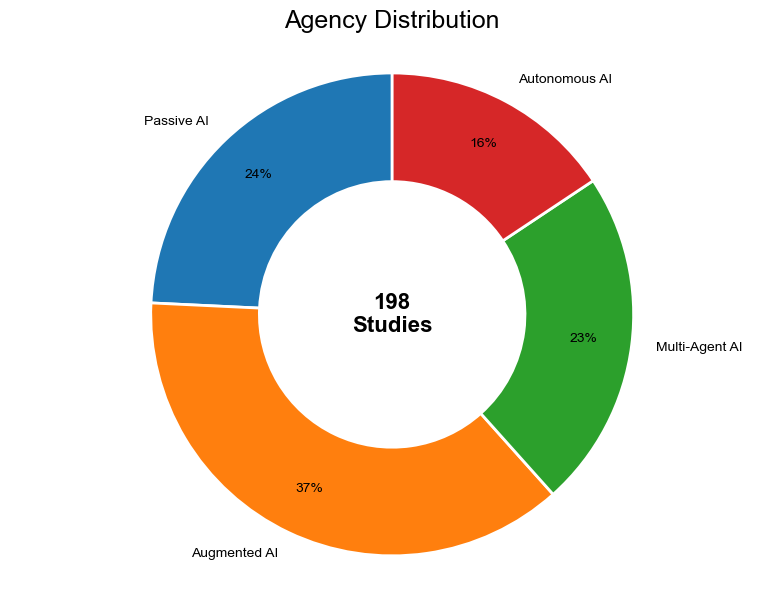

In [16]:
import matplotlib.pyplot as plt

labels = [
    'Passive AI',
    'Augmented AI',
    'Multi-Agent AI',
    'Autonomous AI'
]

sizes = [48, 74, 45, 31]

fig, ax = plt.subplots(figsize=(8, 6), facecolor='white')

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct='%1.0f%%',
    startangle=90,
    pctdistance=0.80,
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2)
)

# Center text
ax.text(
    0, 0,
    '198\nStudies',
    ha='center',
    va='center',
    fontsize=16,
    fontweight='bold'
)

ax.set_title(
    'Agency Distribution',
    fontsize=18,
    pad=15
)

ax.axis('equal')

plt.tight_layout()
plt.show()

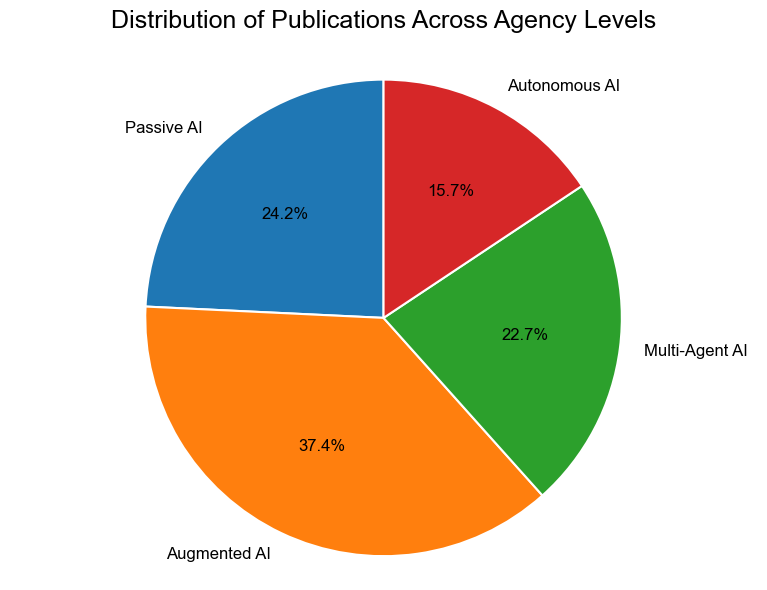

In [17]:
import matplotlib.pyplot as plt

# Agency distribution data
labels = [
    'Passive AI',
    'Augmented AI',
    'Multi-Agent AI',
    'Autonomous AI'
]

sizes = [48, 74, 45, 31]

# Calculate percentages automatically
total = sum(sizes)

fig, ax = plt.subplots(figsize=(8, 6), facecolor='white')

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct=lambda p: f'{p:.1f}%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 12}
)

ax.set_title(
    'Distribution of Publications Across Agency Levels',
    fontsize=18,
    pad=20
)

ax.axis('equal')  # Makes pie chart circular

plt.tight_layout()

# Optional save
# plt.savefig('Figure7_Agency_PieChart.png',
#             dpi=600,
#             bbox_inches='tight')

plt.show()